# Customer Churn Prediction (Telco)

## 1. Executive Summary & Objective
This project develops a predictive machine learning pipeline to identify high risk customer attrition within a telecommunications dataset. By analyzing historical subscriber behavior, demographics, and account metrics, the objective is to isolate key drivers of churn and deploy an operational model. This enables targeted, proactive retention strategies to mitigate financial loss.

## 2. Structural Schema & Data Framework

The dataset profiles 7,043 unique subscribers across 21 architectural attributes, structured into four core operational dimensions:

* Target Variable: Churn (Binary indicator of subscriber departure within the last month).
* Product Infrastructure: Core and value-added utilities including PhoneService, MultipleLines, InternetService (DSL/Fiber optic), OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies.
* Financial Metrics: Account telemetry covering tenure (lifespan in months), Contract type, PaymentMethod, PaperlessBilling, MonthlyCharges, and TotalCharges.
* Demographic Attributes: Baseline profiling metrics comprising gender, SeniorCitizen, Partner, and Dependents.

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Suppress warnings
warnings.filterwarnings('ignore')

# Prevent column truncation in pandas
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Set global visualization styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment initialized successfully.")

Environment initialized successfully.


## 3. Data Ingestion & Initial Structure Inspection

This phase focuses on loading the raw dataset from the local repository path into a Pandas DataFrame to analyze its dimensions, schema, and baseline structural features.

In [2]:
# Load dataset 
data_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)

# Display dimensions
print(f"Dataset Shape: {df.shape}")


df.info()
df.head(10)

Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 4. Deep Structural Inspection

This section validates data types, memory footprints, and structural integrity across all features. The inspection is broken down into initial data cleaning, exploratory observations, and visual outlier detection to establish a clean baseline for model training.

In [3]:
# Check baseline structure and initial null distribution
print("[INFO] DataFrame Baseline Info:")
df.info()

print(f"\n[Initial Nulls]:\n{df.isnull().sum()}")

# Diagnose hidden blanks, apply coerce fix, and verify
hidden_blanks = (df['TotalCharges'] == ' ').sum()
print(f"\n[Diagnostics] Hidden blanks in TotalCharges: {hidden_blanks}")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"[Verified] Post-fix Nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")

[INFO] DataFrame Baseline Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

### 4.1 Structural Audit Observations

A closer look at the data revealed two main issues to fix before model training:

1. The TotalCharges column is saved as text instead of numbers, preventing mathematical operations.
2. Standard checks showed zero missing values, but diagnostics detected 11 hidden blank spaces inside TotalCharges.

Next Steps: Drop the customerID column due to zero predictive power, and remove the 11 rows with missing values to maintain data cleanliness.

In [4]:
# 1. Drop customerID column
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# 2. Drop the 11 missing rows inside TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Reset index
df.reset_index(drop=True, inplace=True)

print(f"[Cleaned] Final Dataset Shape: {df.shape}")

[Cleaned] Final Dataset Shape: (7032, 20)


In [5]:
# Display descriptive statistics for numerical features
print("[INFO] Numerical Features Summary:")
df.describe()

[INFO] Numerical Features Summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
# Check unique categories for all object (categorical) columns
print("[INFO] Categorical Features Unique Values:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].unique()}")

[INFO] Categorical Features Unique Values:
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


### 4.2 Initial Exploratory Insights

Data structure verification and uniqueness analysis after cleaning revealed the following statistics:

1. **Numerical Properties:** The finalized dataset contains 7,032 records. Customer tenure now accurately starts from 1 to 72 months, eliminating the invalid 0-month baseline. TotalCharges ranges from 18.80 to 8,684.80.
2. **Categorical Structure:** Zero spelling anomalies or formatting issues exist across text columns. Columns like gender, Partner, and Churn are strictly binary, while Contract and PaymentMethod contain multi-class configurations.

### 4.3 Outlier Detection and Target Variable Visualization

Visual analysis of numerical distributions is performed using box plots to detect potential outliers in continuous attributes such as 'tenure',' monthly charges', and 'total charges'. Additionally, histograms are used to examine data distribution patterns across the target variable to understand churn behavior.

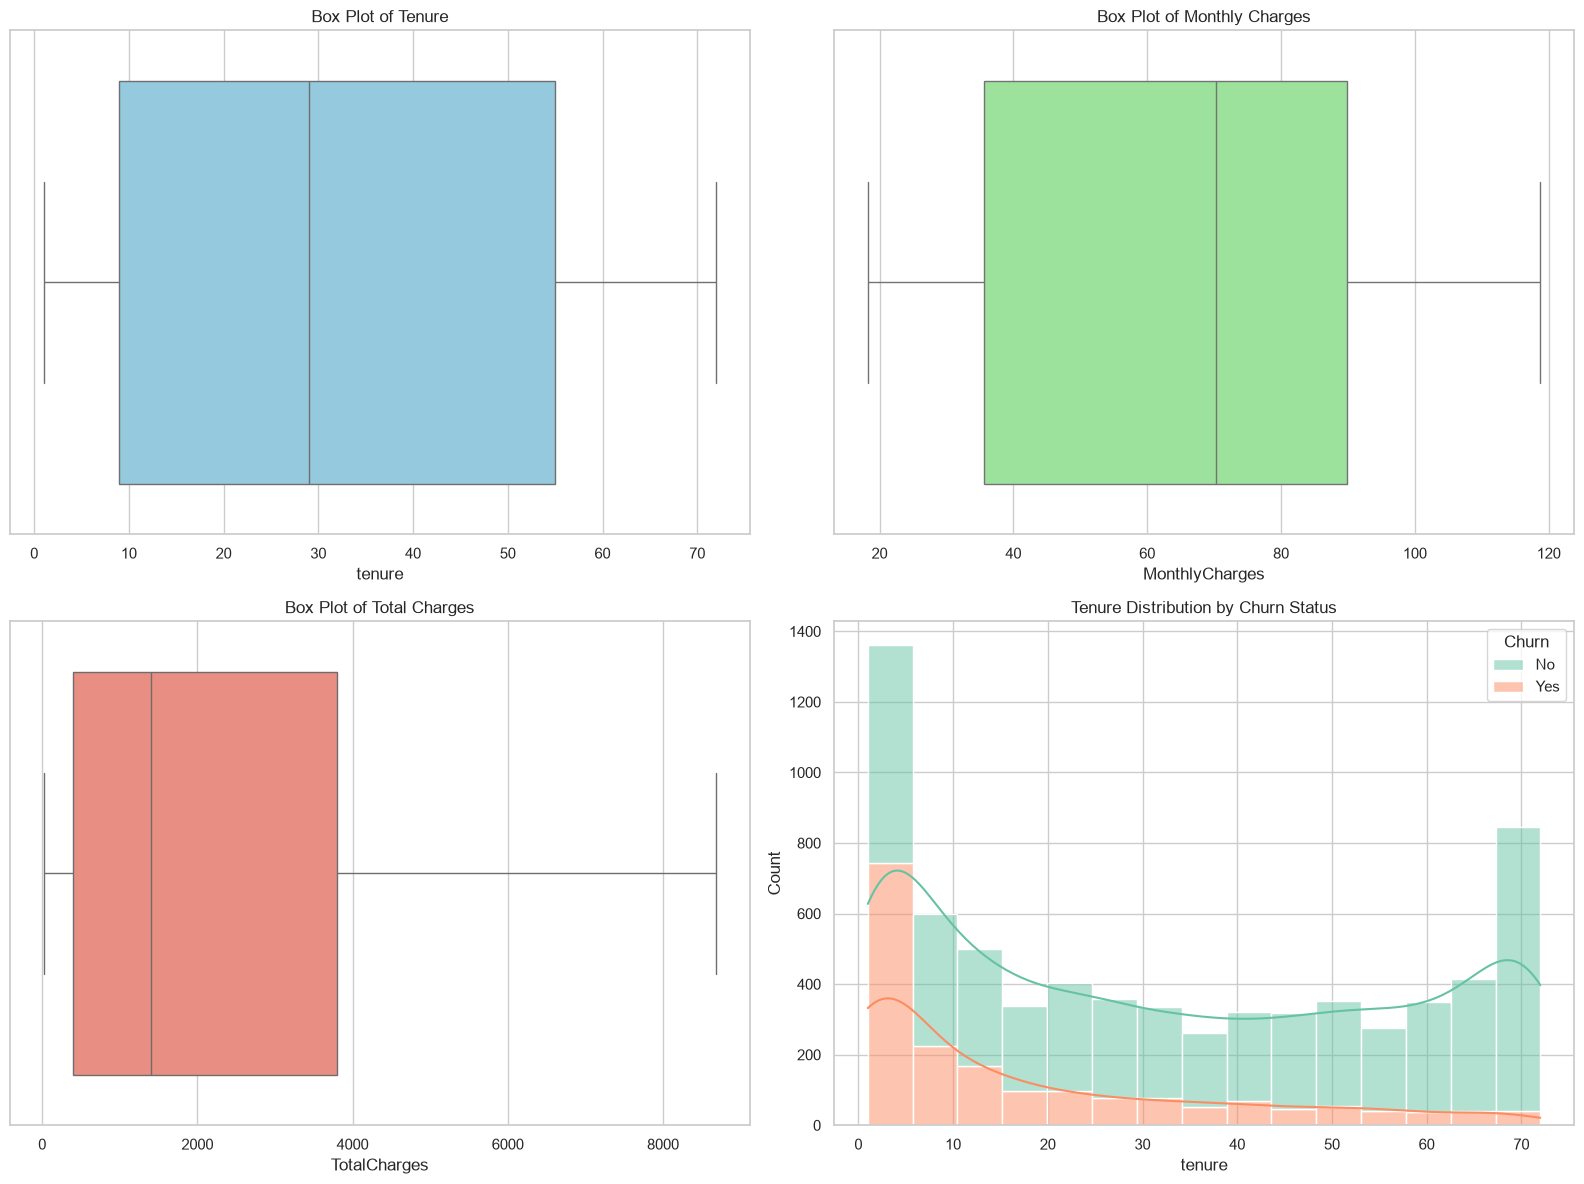

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting environment
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot for tenure to detect outliers
sns.boxplot(x=df['tenure'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Box Plot of Tenure')

# 2. Box plot for MonthlyCharges to detect outliers
sns.boxplot(x=df['MonthlyCharges'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Box Plot of Monthly Charges')

# 3. Box plot for TotalCharges to detect outliers
sns.boxplot(x=df['TotalCharges'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Box Plot of Total Charges')

# 4. Histogram to see tenure distribution based on Churn status
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=True, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Tenure Distribution by Churn Status')

plt.tight_layout()
plt.show()

## 5. Categorical Feature Encoding Strategy

Following the standardization and cleaning of continuous numerical variables, categorical attributes are processed based on data characteristics observed in structural profiling. Text features are classified into two strategic encoding buckets:

1. **Binary Features (2 Categories):** Attributes such as 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', and 'Churn' are explicitly mapped to 0 and 1.
2. **Multi-class Features (3 to 4 Categories):** Attributes with multi-level structural sub-groups (e.g., 'Contract', 'PaymentMethod', 'InternetService') are transformed utilizing One-Hot Encoding to eliminate implicit ordinal bias.

In [8]:
# List of binary categorical columns that contain exactly 2 unique categories
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Map the text categories into professional machine-readable binary formats (0 and 1)
binary_mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
df[binary_cols] = df[binary_cols].map(lambda x: binary_mapping.get(x, x)).astype(int)

# Display the first 5 records to verify the binary transformation
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### 5.1 Multi-class Categorical Encoding via One-Hot Technique

The remaining categorical columns contain 3 or 4 unique text values. To prevent machine learning algorithms from assuming an incorrect numerical hierarchy or implicit order, One-Hot Encoding is applied to expand features such as 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', and 'PaymentMethod' into distinct binary columns.

In [9]:
# Define multi-class categorical columns
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# Apply One-Hot Encoding and convert to integer values
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True, dtype=int)

# Verify structural dimensions and data types
print("[INFO] Final Encoded Dataset Dimensions:")
print(f"Dataset Shape: {df.shape}")
df.info()

[INFO] Final Encoded Dataset Dimensions:
Dataset Shape: (7032, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  Multi

In [10]:
df.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,0,0,0,0,8,1,1,99.65,820.50,1,0,1,1,0,0,...,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0
6,1,0,0,1,22,1,1,89.10,1949.40,0,0,1,1,0,0,...,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0
7,0,0,0,0,10,0,0,29.75,301.90,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
8,0,0,1,0,28,1,1,104.80,3046.05,1,0,1,1,0,0,...,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0
9,1,0,0,1,62,1,0,56.15,3487.95,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0


## 6. Feature Correlation and Exploratory Visual Analysis

Now that the dataset is fully cleaned and encoded into a unified structured numerical matrix, this phase evaluates the statistical relationships between input features and the target variable 'Churn'. This analysis identifies which financial metrics and product attributes serve as the strongest drivers of customer attrition.

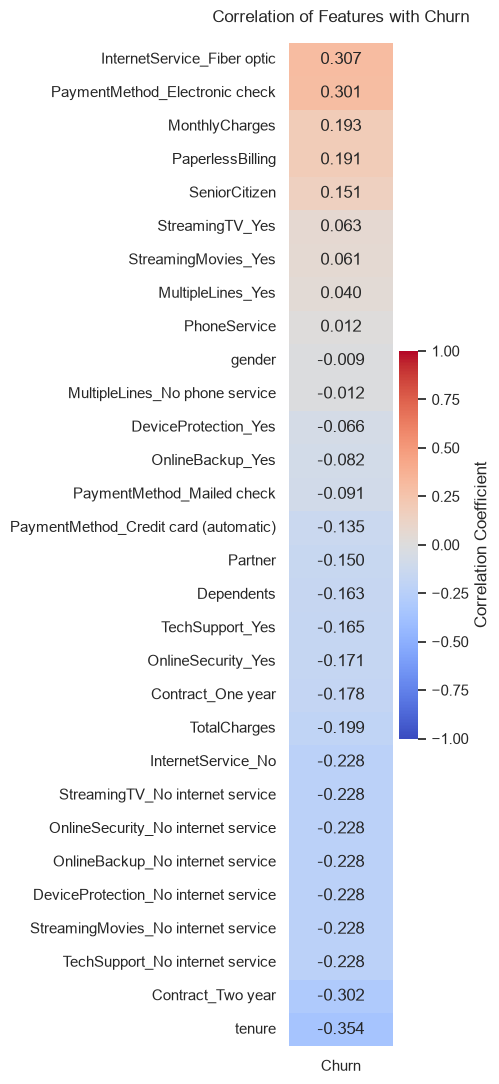

In [11]:
# Compute correlation matrix and isolate correlation with Churn safely
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False).copy()

# Remove Churn self-reference row
churn_corr = churn_corr.drop(index='Churn')

# Set up and display the enhanced correlation heatmap
plt.figure(figsize=(5, 11))
sns.heatmap(churn_corr, 
            annot=True, 
            cmap='coolwarm', 
            center=0,  # Forces the neutral point to be perfectly centered
            vmin=-1, 
            vmax=1, 
            fmt=".3f", 
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation of Features with Churn', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

### 6.1 Feature Correlation Key Findings

#### 1. Negative Correlation (Inversely Proportional to Churn)
* **'tenure' (-0.354):** Shows a strong negative correlation, indicating that extended customer lifespan aligns with lower attrition rates. This underscores the structural value of long-term customer retention.
* **'Contract_Two year' (-0.302) and 'Contract_One year' (-0.178):** Long-term contractual commitments act as strong structural anchors, significantly lowering churn probability relative to month to month subscriptions.

#### 2. Positive Correlation (Directly Proportional to Churn)
* **'InternetService_Fiber optic' (+0.307):** Reflects a high churn propensity. This anomaly flags potential business friction points, such as premium pricing tiers, technical support limitations, or aggressive competitor targeting.
* **'PaymentMethod_Electronic check' (+0.301):** Associated with higher churn rates, indicating potential billing friction or a correlation with short-term, transactional user behaviors.

## 7. Multicollinearity and Variance Inflation Factor (VIF) Audit

Prior to configuring model training parameters, independent variables must be audited for 'Multicollinearity' a statistical anomaly where highly correlated input features destabilize model weights and distort feature importance. This structural diagnostic is executed utilizing the 'Variance Inflation Factor' (VIF) metric after dropping or collapsing redundant dummy features to prevent perfect multicollinearity and ensure a stable data matrix.

In [12]:
# Collapse redundant 'No internet service' columns into a single structural feature
no_internet_cols = [col for col in df.columns if 'No internet service' in col]
df['No_internet_service'] = df[no_internet_cols].any(axis=1).astype(int)
df = df.drop(columns=no_internet_cols)

# Drop redundant phone column to prevent perfect multicollinearity with PhoneService
if 'MultipleLines_No phone service' in df.columns:
    df = df.drop(columns=['MultipleLines_No phone service'])

print(f"[INFO] Redundant columns collapsed successfully. Current Dataset Shape: {df.shape}")

df.head()

[INFO] Redundant columns collapsed successfully. Current Dataset Shape: (7032, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0


In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Isolate independent variables by dropping the target
X = df.drop(columns=['Churn'])

# Dynamically calculate VIF scores across all independent features
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort findings to isolate features inflating model variance
vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

# Render the structural multicollinearity report
print("--- Variance Inflation Factor (VIF) Report ---")
print(vif_data.to_string(index=False))

--- Variance Inflation Factor (VIF) Report ---
                              Feature        VIF
                  No_internet_service        inf
                   InternetService_No        inf
                       MonthlyCharges 212.353073
                         PhoneService  47.244378
                         TotalCharges  21.374002
                               tenure  20.482153
          InternetService_Fiber optic  17.695260
                  StreamingMovies_Yes   5.090603
                      StreamingTV_Yes   4.928957
                    Contract_Two year   3.487502
                 DeviceProtection_Yes   2.992570
                     PaperlessBilling   2.956951
       PaymentMethod_Electronic check   2.955994
                     OnlineBackup_Yes   2.909898
                    MultipleLines_Yes   2.861614
                              Partner   2.824725
                      TechSupport_Yes   2.758343
                   OnlineSecurity_Yes   2.682712
           PaymentMeth

### 7.1 VIF Audit Observations and Strategic Model Selection Rationales

The generated Variance Inflation Factor (VIF) matrix indicates severe collinearity within the independent feature space. Specifically, 'MonthlyCharges' (VIF: 212.353) and 'PhoneService' (VIF: 47.244) exhibit highly elevated metrics, confirming substantial shared variance structures with other encoded attributes. Furthermore, 'No_internet_service' returned a 'NaN' score due to perfect multicollinearity (100% inverse correlation) with 'InternetService_No'.

#### Architectural Remediation and Model Choices:
To mitigate this structural multicollinearity and address the inherent class imbalance (~26% churn distribution), linear estimators (such as Logistic Regression)—which destabilize under high VIF—are systematically excluded from the primary pipeline. Instead, the architecture pivots to Tree-based ensemble models ('RandomForest', 'LightGBM', and 'XGBoost') and proactive feature purging due to the following structural advantages:

1. **Feature Purging for Stability:** Prior to model training, 'MonthlyCharges' and 'No_internet_service' will be dropped from the independent variable matrix ($X$) to eliminate the worst multicollinearity inflation.
2. **Robustness to Remaining Multicollinearity:** Tree-based architectures isolate node splits sequentially based on feature importance or impurity reduction metrics. Remaining redundant variables (like 'TotalCharges' or 'tenure') compete for splits without destabilizing estimator weights or predictive performance.
3. **Imbalance Mitigation Capability:** Tree algorithms natively support structural balancing mechanisms (e.g., class weight parameterization) and respond robustly to subsequent classification threshold tuning.

### 7.2 Global Feature Purging for Structural Stability

Prior to isolating the target variable and executing data partitioning, the feature space must be globally stabilized based on the VIF diagnostic outcomes. To eliminate severe multicollinearity inflation and resolve mathematical singularities, the columns 'MonthlyCharges' and 'No_internet_service' are systematically purged from the master DataFrame. This ensures that downstream estimators receive a structurally clean and un-inflated data matrix.

In [14]:
# Purge high VIF features identified in the audit to globally stabilize the dataset
df = df.drop(columns=['MonthlyCharges', 'No_internet_service'])

print(f"[SUCCESS] High VIF columns purged globally. Current Cleaned Dataset Shape: {df.shape}")

[SUCCESS] High VIF columns purged globally. Current Cleaned Dataset Shape: (7032, 23)
